MAP iter =  9000 , TV + Dat = 6597.349034
MAP done
ILA iter =  9000 , TV + Dat = 16878.039300
ILA done


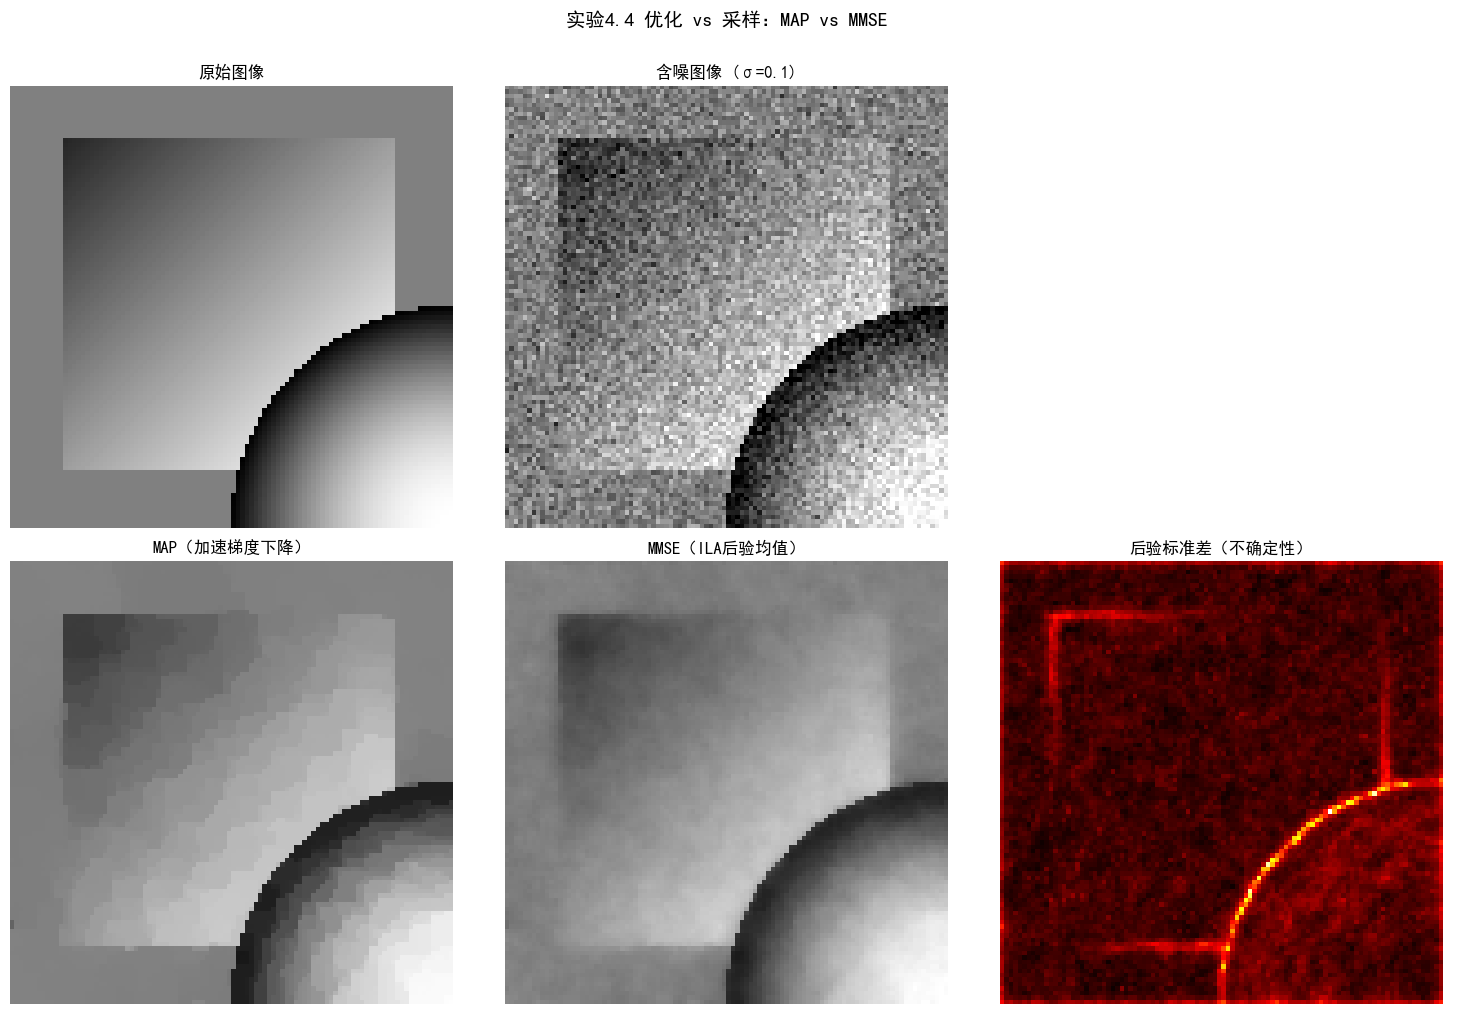

核心洞见：ILA 仅比加速梯度下降多了一个噪声项。
  优化算法 + 噪声 = 采样算法


In [1]:
"""
实验4.4 优化 vs 采样：MAP vs MMSE（加速梯度下降 vs ILA）
对应章节：4.3（ULA=梯度下降+噪声）、4.6（ILA=加速梯度下降+噪声）
素材来源：Mathematics.../Teaching Unit 3/Labs/Lab_2.zip -> opt_vs_sample.ipynb
  - Cell 3: Du() 函数
  - Cell 4: DTp() 函数
  - Cell 5: 合成图像生成代码
  - Cell 6: 加噪声代码
  - Cell 7: 加速梯度下降 MAP
  - Cell 8: 加速ULA/ILA MMSE
  关键观察：ILA 仅比加速梯度下降多了一个噪声项
"""

import numpy as np
import torch
from matplotlib import pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ============================================================
# Du: 离散梯度算子（取自 opt_vs_sample.ipynb Cell 3）
# ============================================================
def Du(u):
    M, N = u.shape
    Du_out = torch.zeros((2, M, N))
    # Neumann boundary
    Du_out[0, :, :-1] += u[:, 1:] - u[:, :-1]
    Du_out[1, :-1, :] += u[1:, :] - u[:-1, :]
    return Du_out

# ============================================================
# DTp: 伴随散度算子（取自 opt_vs_sample.ipynb Cell 4）
# ============================================================
def DTp(p):
    C, M, N = p.shape
    DTp_out = torch.zeros((M, N))
    # Neumann boundary
    DTp_out[:, 1:] += p[0, :, :-1]
    DTp_out[:, :-1] -= p[0, :, :-1]
    DTp_out[1:, :] += p[1, :-1, :]
    DTp_out[:-1, :] -= p[1, :-1, :]
    return DTp_out

# ============================================================
# 合成图像（取自 opt_vs_sample.ipynb Cell 5）
# ============================================================
N = 100
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)

X, Y = np.meshgrid(x, y)

u1 = 0*X+0.5
u2 = X+Y
u2 -= u2.min()
u2 /= u2.max()

u3 = np.clip(1-((1-X)**2+(1-Y)**2), a_min=0, a_max=None)
u3 -= u3.min()
u3 /= u3.max()

m1 = 0*X
m1[N//8:-N//8, N//8:-N//8]=1
u = u1
u[m1==1] = u2[m1==1]*1.25

m2 = 0*X
m2[(X-1)**2+(Y-1)**2 <= 1] = 1
u[m2==1] = u3[m2==1]

# ============================================================
# 加噪声（取自 opt_vs_sample.ipynb Cell 6）
# ============================================================
sigma = 0.1
f = u + np.random.randn(N, N)*sigma


# ============================================================
# MAP：加速梯度下降（取自 opt_vs_sample.ipynb Cell 7）
# ============================================================
lamb = 10.0
eps = 1e-03
theta = 0.99
L = lamb*8/eps + 1/sigma**2
tau = 2/L

f_ = torch.from_numpy(f.copy())
u_map = torch.from_numpy(f.copy())
u_old = torch.from_numpy(f.copy())

maxit = 10000
check = 1000

for it in range(0, maxit):

    # Compute gradient
    diff_u = Du(u_map)
    grad_u = lamb*DTp(diff_u/torch.clamp(torch.abs(diff_u), min=eps)) + (u_map-f_)/sigma**2
    
    # Accelerated gradient descent update (Nesterov momentum)
    u_i = u_map + theta*(u_map-u_old)
    u_old = u_map.clone()
    u_map = u_i - tau*grad_u
    
    if it%check == 0:
        TV = lamb*torch.abs(diff_u).sum()
        Dat = torch.sum((u_map-f_)**2/(2*sigma**2))
        print("MAP iter = ", it,
              ", TV + Dat =", "{:3.6f}".format(TV.cpu().numpy() + Dat.cpu().numpy()),
              end="\r")

print("\nMAP done")


# ============================================================
# MMSE：加速ULA / ILA（取自 opt_vs_sample.ipynb Cell 8）
# 与MAP的唯一区别：多了噪声项 torch.randn*sqrt(2*tau*(1-theta))
# ============================================================
lamb = 20.0
eps = 1e-03
theta = 0.99
L = lamb*8/eps + 1/sigma**2
tau = 2/L

f_ = torch.from_numpy(f.copy())
u_ila = torch.from_numpy(f.copy())
u_old_ = torch.from_numpy(f.copy())

maxit = 10000
u_sum_ = 0
u_sqr_ = 0

for it in range(0, maxit):

    # Compute gradient (same as MAP)
    diff_u = Du(u_ila)
    grad_u = lamb*DTp(diff_u/torch.clamp(torch.abs(diff_u), min=eps)) + (u_ila-f_)/sigma**2
   
    # ILA update = accelerated gradient descent + NOISE
    u_i = u_ila + theta*(u_ila-u_old_)
    u_old_ = u_ila.clone()
    u_ila = u_i - tau*grad_u + torch.randn((N,N))*np.sqrt(2*tau*(1-theta))
    
    u_sum_ += u_ila
    u_sqr_ += u_ila**2
   
    if it%check == 0:
        TV = lamb*torch.abs(diff_u).sum()
        Dat = torch.sum((u_ila-f_)**2/(2*sigma**2))
        print("ILA iter = ", it,
              ", TV + Dat =", "{:3.6f}".format(TV.cpu().numpy() + Dat.cpu().numpy()),
              end="\r")

print("\nILA done")

u_avg_ = u_sum_/maxit
u_var_ = u_sqr_/maxiter if 'maxiter' in dir() else u_sqr_/maxit - u_avg_**2
# 修正：按原代码逻辑
u_avg_ = u_sum_/maxit
u_var_ = u_sqr_/maxit - u_avg_**2


# ============================================================
# 可视化
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0][0].imshow(u, cmap='gray', vmin=0, vmax=1)
axes[0][0].set_title('原始图像')
axes[0][0].axis('off')

axes[0][1].imshow(f, cmap='gray', vmin=0, vmax=1)
axes[0][1].set_title(f'含噪图像 (σ={sigma})')
axes[0][1].axis('off')

axes[0][2].axis('off')

axes[1][0].imshow(u_map.reshape(N, N), cmap='gray', vmin=0, vmax=1)
axes[1][0].set_title('MAP（加速梯度下降）')
axes[1][0].axis('off')

axes[1][1].imshow(u_avg_.reshape(N, N), cmap='gray', vmin=0, vmax=1)
axes[1][1].set_title('MMSE（ILA后验均值）')
axes[1][1].axis('off')

axes[1][2].imshow(torch.sqrt(u_var_), cmap='hot')
axes[1][2].set_title('后验标准差（不确定性）')
axes[1][2].axis('off')

fig.suptitle('实验4.4 优化 vs 采样：MAP vs MMSE', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('实验4_4_MAP_vs_MMSE.png', dpi=150, bbox_inches='tight')
plt.show()

print("核心洞见：ILA 仅比加速梯度下降多了一个噪声项。")
print("  优化算法 + 噪声 = 采样算法")
